<a href="https://colab.research.google.com/github/isha0902/Deep_learning/blob/main/DLG_Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
data = fetch_covtype()

X = data.data
y = data.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (581012, 54)
y shape: (581012,)


In [3]:
print("Unique classes:", np.unique(y))
print("Number of classes:", len(np.unique(y)))

Unique classes: [1 2 3 4 5 6 7]
Number of classes: 7


In [4]:
class_counts = pd.Series(y).value_counts().sort_index()

print(class_counts)


1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64


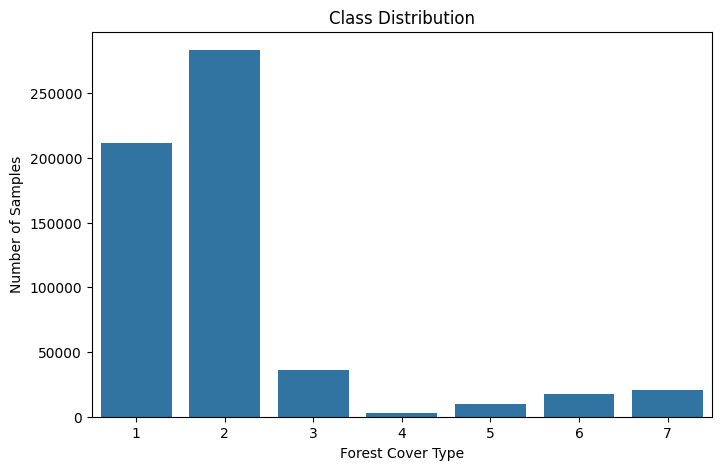

In [5]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values
)

plt.xlabel("Forest Cover Type")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")
plt.show()

In [6]:
y = y - 1

print(np.unique(y))


[0 1 2 3 4 5 6]


In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [8]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [9]:
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (464809, 54)
Validation: (58101, 54)
Testing: (58102, 54)


In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

In [11]:
print("Training mean:", np.mean(X_train))
print("Training standard deviation:", np.std(X_train))

Training mean: -2.406137286684203e-17
Training standard deviation: 0.9999999999999415


In [12]:
num_classes = 7

y_train_onehot = np.eye(num_classes)[y_train]
y_val_onehot = np.eye(num_classes)[y_val]
y_test_onehot = np.eye(num_classes)[y_test]

In [13]:
print(y_train_onehot.shape)
print(y_train_onehot[0])

(464809, 7)
[0. 1. 0. 0. 0. 0. 0.]


In [14]:
N = len(y_train)
K = 7

class_counts = np.bincount(y_train)

class_weights = N / (K * class_counts)

print("Class counts:")
print(class_counts)

print("\nClass weights:")
print(class_weights)

Class counts:
[169472 226640  28603   2198   7594  13894  16408]

Class weights:
[ 0.39181272  0.29298132  2.32147976 30.20986611  8.74391437  4.77913385
  4.04688479]


In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [16]:
model = Sequential([

    Dense(64, activation='relu', input_shape=(54,)),

    Dense(32, activation='relu'),

    Dense(16, activation='relu'),

    Dense(7, activation='softmax')
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,247 (24.40 KB)

 Trainable params: 6,247 (24.40 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

In [19]:
history = model.fit(
    X_train,
    y_train_onehot,

    validation_data=(
        X_val,
        y_val_onehot
    ),

    epochs=100,

    batch_size=128,

    class_weight={
        i: class_weights[i]
        for i in range(7)
    },

    callbacks=[early_stopping],

    verbose=1
)

Epoch 1/100
3632/3632 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.4548 - loss: 0.9472 - val_accuracy: 0.6043 - val_loss: 0.9515
Epoch 2/100
3632/3632 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.6104 - loss: 0.6730 - val_accuracy: 0.6308 - val_loss: 0.8286
Epoch 3/100
3632/3632 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6291 - loss: 0.6131 - val_accuracy: 0.6450 - val_loss: 0.7971
Epoch 4/100
3632/3632 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.6421 - loss: 0.5791 - val_accuracy: 0.6449 - val_loss: 0.7815
Epoch 5/100
3632/3632 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6532 - loss: 0.5559 - val_accuracy: 0.6723 - val_loss: 0.7262
Epoch 6/100
3632/3632 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6645 - loss: 0.5363 - val_accuracy: 0.6576 - val_loss: 0.7554
Epoch 7/100
3632/3632 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.6728 - loss: 0.5228 - val_accuracy: 0.6851 - val_loss: 0.7220
Epoch 8/100
3632/3632 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6807 - loss: 0

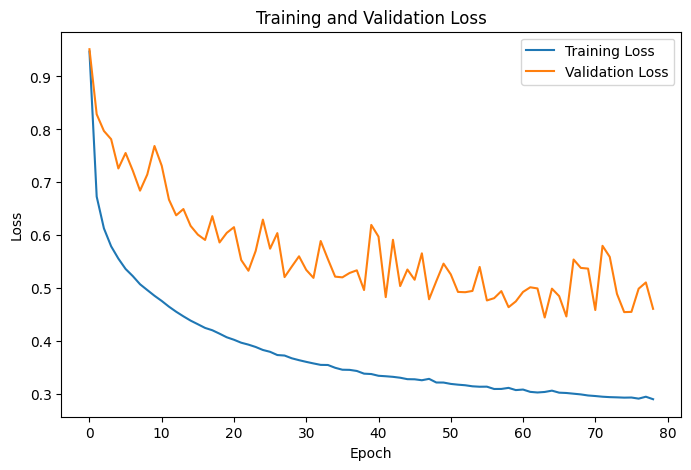

In [20]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()

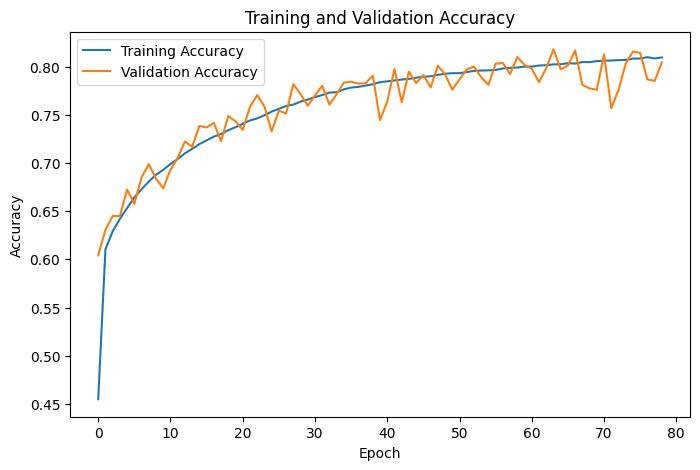

In [21]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.show()

In [22]:
y_pred_prob = model.predict(X_test)

1816/1816 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [23]:
y_pred = np.argmax(y_pred_prob, axis=1)

print(y_pred[:20])

[0 1 1 1 5 1 1 1 1 4 1 3 1 0 0 2 0 0 4 1]


In [24]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8160476403566143


In [25]:
print("Test Accuracy:", accuracy * 100, "%")

Test Accuracy: 81.60476403566143 %


In [26]:
precision = precision_score(
    y_test,
    y_pred,
    average='macro'
)

recall = recall_score(
    y_test,
    y_pred,
    average='macro'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='macro'
)

print("Macro Precision:", precision)
print("Macro Recall:", recall)
print("Macro F1 Score:", f1)

Macro Precision: 0.700506567049611
Macro Recall: 0.8754730052879298
Macro F1 Score: 0.7639476268840987


In [27]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Spruce/Fir",
            "Lodgepole Pine",
            "Ponderosa Pine",
            "Cottonwood/Willow",
            "Aspen",
            "Douglas-fir",
            "Krummholz"
        ]
    )
)

                   precision    recall  f1-score   support

       Spruce/Fir       0.87      0.75      0.80     21184
   Lodgepole Pine       0.84      0.85      0.84     28331
   Ponderosa Pine       0.82      0.83      0.82      3576
Cottonwood/Willow       0.60      0.98      0.75       274
            Aspen       0.43      0.90      0.59       949
      Douglas-fir       0.61      0.85      0.71      1737
        Krummholz       0.73      0.98      0.83      2051

         accuracy                           0.82     58102
        macro avg       0.70      0.88      0.76     58102
     weighted avg       0.83      0.82      0.82     58102



In [28]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[15816  4557     9     0   147    19   636]
 [ 2303 24037   438     2   935   504   112]
 [    0    67  2963   131    29   386     0]
 [    0     0     4   268     0     2     0]
 [    2    70     6     0   858    13     0]
 [    0    14   204    44     4  1471     0]
 [   44     6     0     0     0     0  2001]]


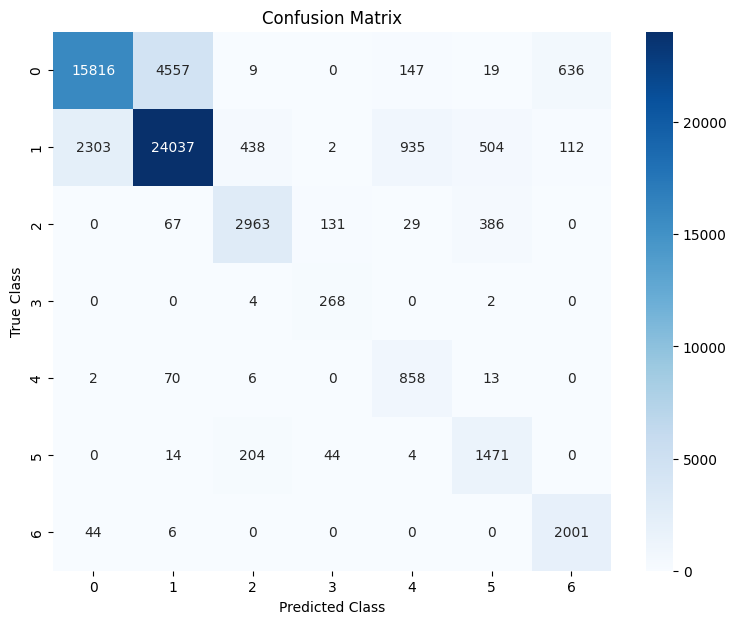

In [29]:
plt.figure(figsize=(9,7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")

plt.show()

In [30]:
f1_scores = f1_score(
    y_test,
    y_pred,
    average=None
)

class_names = [
    "Spruce/Fir",
    "Lodgepole Pine",
    "Ponderosa Pine",
    "Cottonwood/Willow",
    "Aspen",
    "Douglas-fir",
    "Krummholz"
]

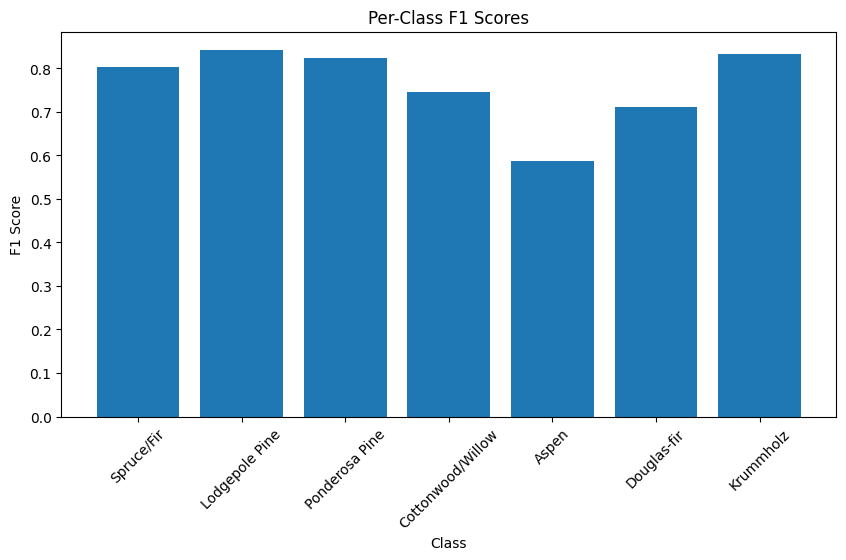

In [31]:
plt.figure(figsize=(10,5))

plt.bar(class_names, f1_scores)

plt.xlabel("Class")
plt.ylabel("F1 Score")
plt.title("Per-Class F1 Scores")

plt.xticks(rotation=45)

plt.show()

In [32]:
true_counts = np.bincount(y_test, minlength=7)
pred_counts = np.bincount(y_pred, minlength=7)

comparison = pd.DataFrame({
    "Class": class_names,
    "True": true_counts,
    "Predicted": pred_counts
})

print(comparison)

               Class   True  Predicted
0         Spruce/Fir  21184      18165
1     Lodgepole Pine  28331      28751
2     Ponderosa Pine   3576       3624
3  Cottonwood/Willow    274        445
4              Aspen    949       1973
5        Douglas-fir   1737       2395
6          Krummholz   2051       2749


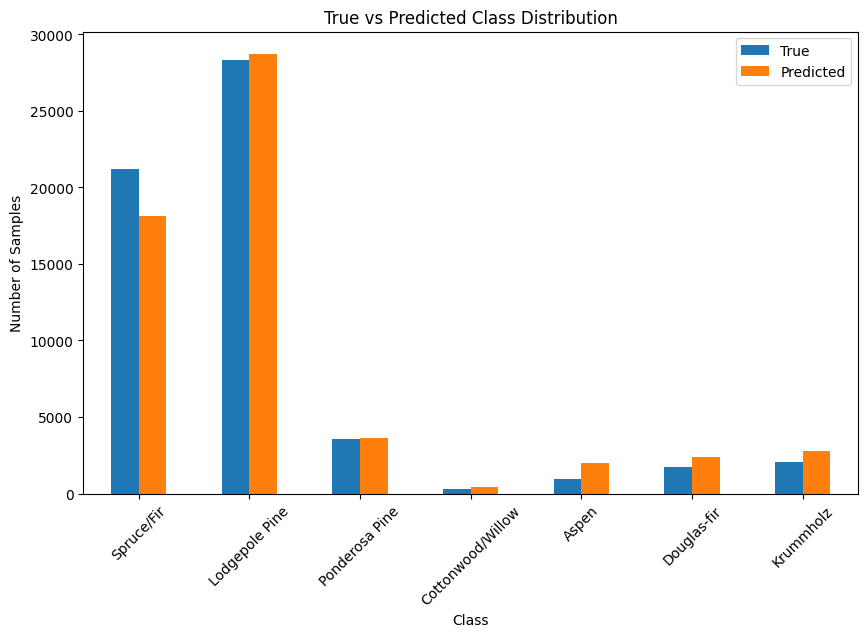

In [33]:
comparison.set_index("Class").plot(
    kind="bar",
    figsize=(10,6)
)

plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("True vs Predicted Class Distribution")

plt.xticks(rotation=45)
plt.show()

In [34]:
print("========== FINAL RESULTS ==========")

print("Test Accuracy :", accuracy)
print("Macro Precision:", precision)
print("Macro Recall   :", recall)
print("Macro F1 Score :", f1)

========== FINAL RESULTS ==========
Test Accuracy : 0.8160476403566143
Macro Precision: 0.700506567049611
Macro Recall   : 0.8754730052879298
Macro F1 Score : 0.7639476268840987
